In [1]:
import torch
import CT.Models.misc as misc
import CT.Inference.Kolmogorov.performance as performance
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# lag_ratio = 5
# LSDM_NS_file_path = "/scratch/ql2221/CT_models/wandb_data/wandb/run-20260106_213428-cnqeswmj/files/checkpoint_last.p"

lag_ratio = 1
LSDM_NS_file_path = "/scratch/ql2221/CT_models/wandb_data/wandb/run-20260112_141849-pg7cty6s/files/checkpoint_last.p"
LSDM_NS = misc.load_LSDM(LSDM_NS_file_path).to(device)

/ext3/miniforge3/lib/python3.12/site-packages/CT/Models/misc.py:94: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(file_string)


In [2]:
LSDM_NS.config

{'model_type': 'ModernUnetDoubleRegressor',
 'input_channels': 3,
 'output_channels': 2,
 'hidden_channels': 64,
 'norm': False,
 'dim_mults': [2, 2, 2],
 'n_blocks': 2,
 'mid_attn': False,
 'is_attn': (False, False, False, False),
 'activation': 'gelu',
 'image_width': 64,
 'image_height': 64,
 'first_embedding_dim': 1000,
 'noise_short_lag': True,
 'different_noise': True,
 'noise_short_lag_more': False,
 'fix_short_lag': 1,
 'second_embedding_dim': 1000,
 'third_embedding_dim': 512,
 'save_path': '/scratch/ql2221/CT_models/wandb_data/wandb/run-20260112_141849-pg7cty6s/files',
 'save_name': 'model_weights.pt',
 'diffusion_steps': 1000,
 'regression_output_dim': 1000,
 'regression_target': 'pred_both_noise_level',
 'lagsteps': 128,
 'noise_schedule': 'Cosine',
 'project': 'CT',
 'wandb_run_name': 'Emulator_step_size',
 'wandb_log_freq': 100,
 'ddp': False,
 'PDE': 'Kolmogorov',
 'file_path': '/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/Emulator_step_size_training_data.p',
 's

In [3]:
#load data
data_dict = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/Long_numerical_rollout.p")
data = data_dict["data"]/4.44
# print(data.shape)

/state/partition1/job-1291535/ipykernel_1092750/1925875663.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_dict = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_fl

In [4]:
x = data[0:1].to(device)
x_t = x[:,-1:]
short_lag = torch.tensor([1]).to(device)
long_lag = torch.tensor([99]).to(device)
x_short = x[:,-(short_lag * lag_ratio)-1:-(short_lag * lag_ratio)].to(device)
x_long = x[:,-(long_lag * lag_ratio)-1:-(long_lag * lag_ratio )].to(device)
s_short = 500
x_short = LSDM_NS._forward_diffusion(x_short, s_short).to(device)
s_t = 800
x_t_noised = LSDM_NS._forward_diffusion(x_t, s_t).to(device)
x_in = torch.cat((x_long, x_short, x_t_noised),dim = 1)
pred_s = LSDM_NS.model.ratio_class_both(x_in, None, None, long_lag).to(device)
denoised = LSDM_NS.denoising_with_refinement(x_in, long_lag, pred_s, forward_diff = False)

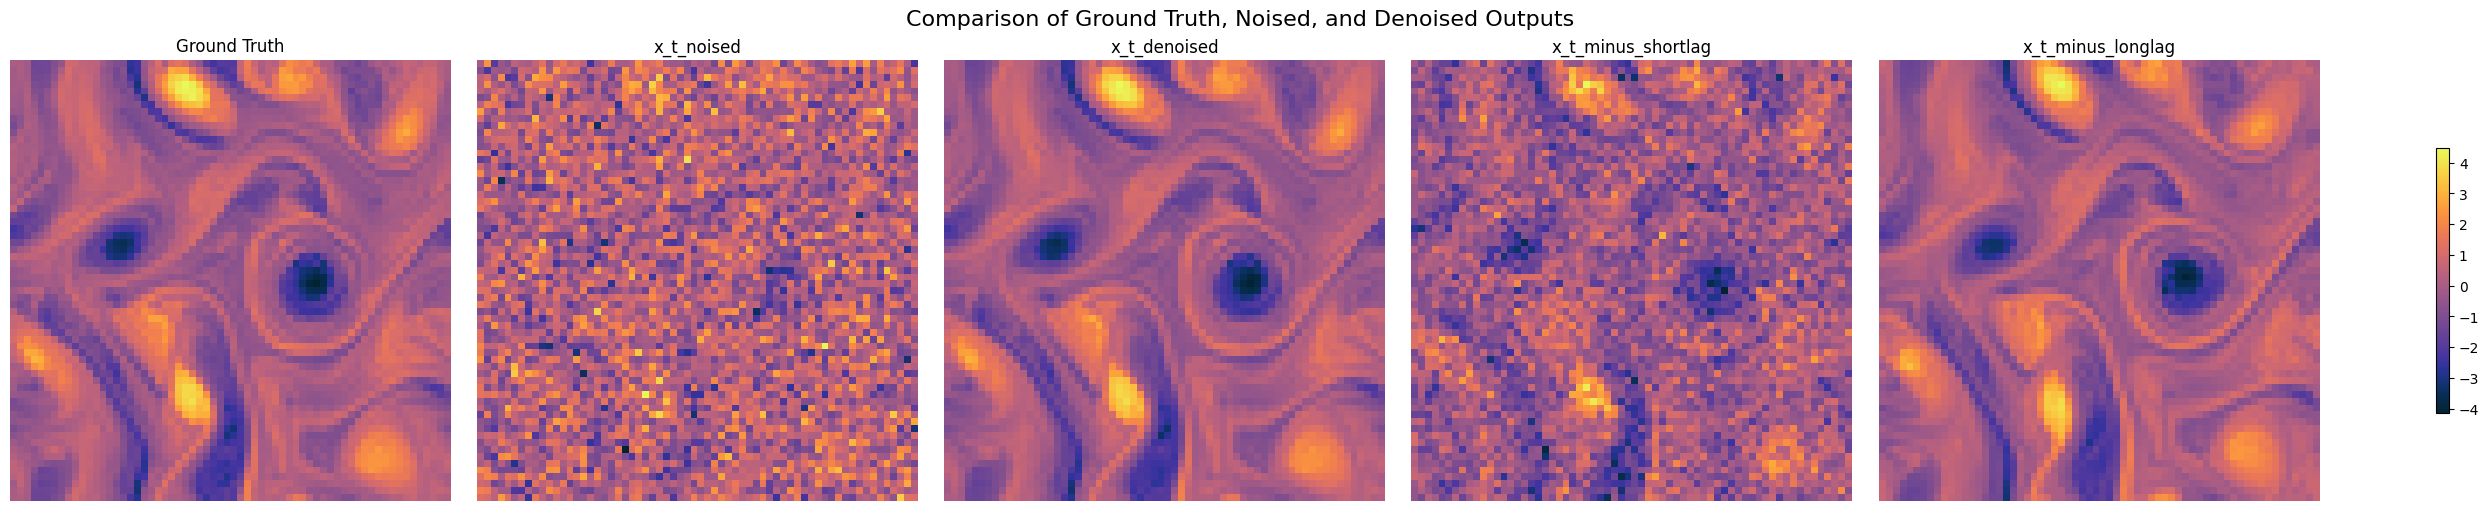

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean

tensors = [
    x_t,                
    x_t_noised,
    denoised[:,-1:],
    x_short,
    x_long
]
titles = [
    'Ground Truth',
    'x_t_noised',
    'x_t_denoised',
    'x_t_minus_shortlag',
    'x_t_minus_longlag'
]

# make the figure
fig, axes = plt.subplots(1, len(tensors), figsize=(25, 5), constrained_layout=True)

for ax, tensor, title in zip(axes, tensors, titles):
    # squeeze to (H, W)
    tensor_np = tensor.squeeze().detach().cpu().numpy()
    im = ax.imshow(tensor_np, cmap=cmocean.cm.thermal)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# add colorbar across all axes
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
fig.suptitle(r'Comparison of Ground Truth, Noised, and Denoised Outputs', fontsize=16)

plt.savefig("comparison_diffusion.png", dpi=300, bbox_inches='tight')
plt.show()


In [7]:
x = data.to(device)
# Emu_file_path = '/scratch/ql2221/Emulator_models/wandb_data/wandb/run-20251028_103612-lmys64ex/files/checkpoint_best.p'
Emu_file_path = "/scratch/ql2221/Emulator_models/wandb_data/wandb/run-20251209_020651-5dziwzqp/files/checkpoint_best.p" #worse emulator
Emu = misc.load_Emulator(Emu_file_path).to(device)
rollout = performance.LSDM_NS_inference(x[:,0:1], Emu, LSDM_NS, n_steps=30000, short_lag_int = 1, freq = lag_ratio, lag_ratio = lag_ratio, s_init = -1, max_long_lag = 99, starting_time = 1000, sigma=None, silence=False, forward_diff = True, fix_short = False, device = "cuda")

100%|██████████| 29999/29999 [35:37<00:00, 14.04it/s]  


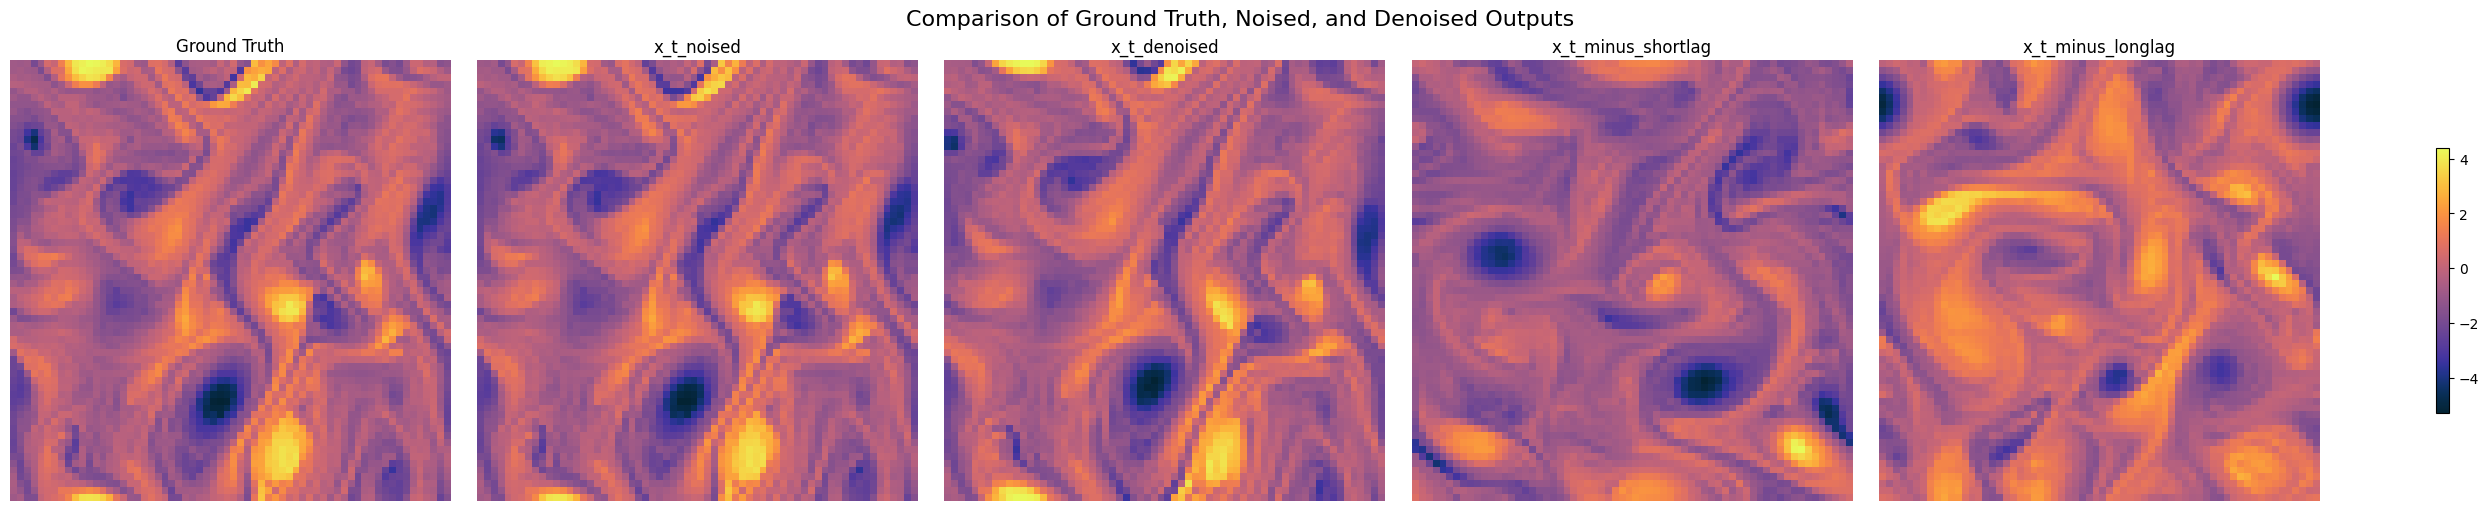

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean
T = 30000
B = 4
tensors = [
    rollout[B:B+1,T-1:T],                
    rollout[B:B+1,T-10:T-9],
    rollout[B:B+1,T-100:T-99],
    rollout[B:B+1,T-1000:T-999],
    rollout[B:B+1,T-10000:T-9999]
]
titles = [
    'Ground Truth',
    'x_t_noised',
    'x_t_denoised',
    'x_t_minus_shortlag',
    'x_t_minus_longlag'
]

# make the figure
fig, axes = plt.subplots(1, len(tensors), figsize=(25, 5), constrained_layout=True)

for ax, tensor, title in zip(axes, tensors, titles):
    # squeeze to (H, W)
    tensor_np = tensor.squeeze().detach().cpu().numpy()
    im = ax.imshow(tensor_np, cmap=cmocean.cm.thermal)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# add colorbar across all axes
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
fig.suptitle(r'Comparison of Ground Truth, Noised, and Denoised Outputs', fontsize=16)

plt.savefig("comparison_diffusion.png", dpi=300, bbox_inches='tight')
plt.show()

In [10]:
emu_rollout = performance.run_emu(x[:,0:1],emu = Emu, n_steps=30000,silent=False,sigma=None)

100%|██████████| 29999/29999 [05:05<00:00, 98.11it/s] 


In [11]:
tensor = torch.cat((x[:,:emu_rollout.shape[1]], emu_rollout, rollout), dim = 0)
torch.save(tensor, "/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/LSDM_inference_2.p")

titles = [ "GT", "GT", "GT", "GT", "GT", "Emu", "Emu", "Emu", "Emu", "Emu", "Therm", "Therm", "Therm", "Therm", "Therm"]

In [ ]:
import numpy as np
import matplotlib
matplotlib.use("Agg")  # headless / non-interactive backend for rendering frames
import matplotlib.pyplot as plt

from moviepy.video.io.ffmpeg_writer import FFMPEG_VideoWriter
from tqdm import tqdm


def make_movie_moviepy(
    state_vector,
    save_path="emulator_movie.mp4",
    fps=30,
    vmin=None,
    vmax=None,
    stride=10,
    titles=None,
    cmap="viridis",
    interpolation="nearest",
    dpi=150,
    bitrate="8000k",
):
    """
    Create a 3x5 grid movie from a 4D tensor/array of shape (B, T, H, W), using only every `stride`-th frame.
    - B must be 15 (3 rows x 5 columns).
    - One shared colorbar per row (fixed over time).
    - Optional custom title per panel via `titles` (len 15, row-major).

    Uses MoviePy's FFmpeg writer (FFmpeg required for MP4).
    """

    # Convert to numpy without requiring torch as a dependency at import time
    if hasattr(state_vector, "detach"):  # likely a torch.Tensor
        arr = state_vector.detach().cpu().numpy()
    else:
        arr = np.asarray(state_vector)

    if arr.ndim != 4:
        raise ValueError(f"Expected [B, T, H, W], got {arr.shape}")
    B, T, H, W = arr.shape
    if B != 15:
        raise ValueError(f"B must be 15 for a 3x5 grid, got B={B}")
    if T < 1:
        raise ValueError("T must be >= 1")

    # Frame indices to use
    stride = max(1, int(stride))
    frame_indices = list(range(0, T, stride))
    if frame_indices[-1] != T - 1:
        frame_indices.append(T - 1)  # ensure last frame is included

    def bidx(r, c):
        return r * 5 + c

    # Determine color limits
    row_limits = []
    if vmin is not None or vmax is not None:
        gmin, gmax = vmin, vmax
        if gmin is None or gmax is None:
            used = arr[:, frame_indices, :, :]
            amin = float(np.nanmin(used))
            amax = float(np.nanmax(used))
            if gmin is None:
                gmin = amin
            if gmax is None:
                gmax = amax
        row_limits = [(gmin, gmax)] * 3
    else:
        for r in range(3):
            row_data = arr[bidx(r, 0):bidx(r, 0) + 5, :, :, :]  # [5, T, H, W]
            row_used = row_data[:, frame_indices, :, :]
            rmin = float(np.nanmin(row_used))
            rmax = float(np.nanmax(row_used))
            row_limits.append((rmin, rmax))

    # Titles
    if titles is None:
        titles = [f"Panel {i+1}" for i in range(15)]
    if len(titles) != 15:
        raise ValueError("`titles` must have length 15 (row-major order).")

    # Figure and axes (reserve right margin for colorbars)
    fig, axes = plt.subplots(3, 5, figsize=(15, 9), dpi=dpi, squeeze=False)
    fig.subplots_adjust(
        left=0.03, right=0.88, top=0.92, bottom=0.05,
        wspace=0.03, hspace=0.15
    )

    ims = []
    for r in range(3):
        vmin_r, vmax_r = row_limits[r]

        # Create images for this row
        for c in range(5):
            ax = axes[r, c]
            im = ax.imshow(
                arr[bidx(r, c), frame_indices[0]],
                cmap=cmap,
                vmin=vmin_r,
                vmax=vmax_r,
                interpolation=interpolation,
                origin="upper",
            )
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(titles[bidx(r, c)], fontsize=10)
            ims.append(im)

        # Colorbar axis placed to the right of the last subplot in this row
        last_ax = axes[r, -1]
        pos = last_ax.get_position()  # figure coordinates

        pad = 0.01
        cbar_w = 0.015
        cax = fig.add_axes([pos.x1 + pad, pos.y0, cbar_w, pos.height])

        cb = fig.colorbar(ims[r * 5], cax=cax)
        cb.set_label(
            f"Row {r+1} scale [{row_limits[r][0]:.3g}, {row_limits[r][1]:.3g}]",
            fontsize=9,
        )

    suptitle = fig.suptitle(f"Timestep {frame_indices[0]}", fontsize=12)

    # Prepare canvas once
    fig.canvas.draw()

    # Helper: render current figure to RGB array (Matplotlib 3.8+ compatible)
    def fig_to_rgb():
        fig.canvas.draw()
        buf = np.asarray(fig.canvas.buffer_rgba())
        return buf[:, :, :3].copy()  # drop alpha channel

    # Update plots for frame i
    def update(i):
        f = frame_indices[i]
        for r in range(3):
            for c in range(5):
                ims[r * 5 + c].set_data(arr[bidx(r, c), f])
        suptitle.set_text(f"Timestep {f}")

    # Get frame size for writer
    first_frame = fig_to_rgb()
    height, width = first_frame.shape[:2]

    # MoviePy low-level writer
    writer = FFMPEG_VideoWriter(
        filename=save_path,
        size=(width, height),
        fps=fps,
        codec="libx264",
        bitrate=bitrate,
        preset="medium",
        ffmpeg_params=["-pix_fmt", "yuv420p"],
    )

    try:
        for i in tqdm(range(len(frame_indices)), desc="Rendering movie"):
            update(i)
            frame = fig_to_rgb()
            writer.write_frame(frame)
    finally:
        writer.close()
        plt.close(fig)

    print(f"Movie saved: {save_path}")


In [12]:
import torch
tensor = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/LSDM_inference_2.p")
titles = [ "GT", "GT", "GT", "GT", "GT", "Emu", "Emu", "Emu", "Emu", "Emu", "Therm", "Therm", "Therm", "Therm", "Therm"]
make_movie_moviepy(
    state_vector=tensor,
    save_path="ICML_NS.mp4",
    fps=30,
    stride=20,          # 400 frames total → ~13 s video
    titles=titles,
    cmap="viridis",
    dpi=150,
    vmin=-4,
    vmax=4,
)

Rendering movie: 100%|██████████| 1501/1501 [05:22<00:00,  4.65it/s]


Movie saved: ICML_NS.mp4
